# 读取LigandMPNN的结果csv文件，按照设计的个数进行排序，取前十的序列构建Protenix的输入json文件

## 按照蛋白链对齐，计算多肽链骨架的RMSD

In [11]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from Bio.PDB import PDBParser, FastMMCIFParser, Superimposer


with open("/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/PepSet_dimer/PDB.list", "r") as f:
    pdbs = [line.strip() for line in f.readlines()]

pdbparser = PDBParser(QUIET=True)
mmcifparser = FastMMCIFParser(QUIET=True)

for pdb in pdbs:
    base_dir = f"/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/pred_v1-pro_nomsa_notemplate-pep_nomsa_notemplate/{pdb}"
    merged_pdb_path = Path(f"./PepSet_dimer/{pdb}.pdb")
    if not os.path.exists(merged_pdb_path):
        raise FileNotFoundError(f"Merged PDB file not found: {merged_pdb_path}")
    
    structure_ref = pdbparser.get_structure('ref', merged_pdb_path)
    chain_L_ref = structure_ref[0]['L']
    ref_atoms = [atom for atom in chain_L_ref.get_atoms() if atom.get_id() in ['N', 'CA', 'C', 'O']]

    rows = []

    for root, dirs, files in os.walk(base_dir):
        if not root.endswith("predictions"):
            continue

        seed = root.split("/")[-2]
        sample_name = root.split("/")[-3]

        candidates = []
        metrics_by_id = {}

        for file in files:
            if file.endswith(".json"):
                sample_id = file.split("_")[-1].split(".")[0]
                json_path = os.path.join(root, file)
                if not os.path.exists(json_path):
                    continue
                df = pd.read_json(json_path)
                metrics_by_id.setdefault(sample_id, {}).update(
                    {
                        "plddt": round(float(df["plddt"].iloc[0]), 4),
                        "pep_plddt": round(float(df["chain_plddt"].iloc[1]), 4),
                        "gpde": round(float(df["gpde"].iloc[0]), 4),
                        "ptm": round(float(df["ptm"].iloc[0]), 4),
                        "iptm": round(float(df["iptm"].iloc[0]), 4),
                        "ranking_score": round(float(df["ranking_score"].iloc[0]), 4),
                    }
                )

            elif file.endswith(".cif"):
                sample_id = file.split("_")[-1].split(".")[0]
                cif_path = os.path.join(root, file)
                if not os.path.exists(cif_path):
                    continue
                structure_pred = mmcifparser.get_structure('pred', cif_path)

                # 预测结构中的 L 链（原逻辑为 'B'）
                try:
                    chain_L_pred = structure_pred[0]['B']
                except KeyError:
                    # 若不存在 B 链，跳过
                    continue

                # 参考结构的蛋白链（选取第一个不为 'L' 的链）
                align_chain_ref = None
                for ch in structure_ref[0]:
                    if ch.id != 'L':
                        align_chain_ref = ch
                        break
                if align_chain_ref is None:
                    continue

                # 预测结构的蛋白链（选取第一个不为预测 L 链的链）
                align_chain_pred = None
                for ch in structure_pred[0]:
                    if ch.id != chain_L_pred.id:
                        align_chain_pred = ch
                        break
                if align_chain_pred is None:
                    continue

                # 取用于对齐的蛋白链骨架原子
                align_ref_atoms = [atom for atom in align_chain_ref.get_atoms() if atom.get_id() in ['N', 'CA', 'C', 'O']]
                align_pred_atoms = [atom for atom in align_chain_pred.get_atoms() if atom.get_id() in ['N', 'CA', 'C', 'O']]
                if len(align_ref_atoms) == 0 or len(align_pred_atoms) == 0:
                    raise ValueError("No backbone atoms found for alignment.")
                if len(align_ref_atoms) != len(align_pred_atoms):
                    # 原子数不一致，无法对齐，跳过
                    raise ValueError("Backbone atom count mismatch for alignment.")

                # 计算对齐变换（基于蛋白链）
                sup = Superimposer()
                try:
                    sup.set_atoms(align_ref_atoms, align_pred_atoms)
                except Exception:
                    raise ValueError("Failed to set atoms for superimposer.")
                rot, tran = sup.rotran

                # 在该变换下计算 L 链骨架的 RMSD
                ref_L_atoms = [atom for atom in chain_L_ref.get_atoms() if atom.get_id() in ['N', 'CA', 'C', 'O']]
                pred_L_atoms = [atom for atom in chain_L_pred.get_atoms() if atom.get_id() in ['N', 'CA', 'C', 'O']]
                if len(ref_L_atoms) == 0 or len(pred_L_atoms) == 0:
                    raise ValueError("No backbone atoms found for L chain.")
                if len(ref_L_atoms) != len(pred_L_atoms):
                    raise ValueError("Backbone atom count mismatch for L chain.")

                ref_coords = np.array([a.get_coord() for a in ref_L_atoms], dtype=float)
                pred_coords = np.array([a.get_coord() for a in pred_L_atoms], dtype=float)
                pred_coords_aligned = pred_coords @ rot + tran

                diffs = ref_coords - pred_coords_aligned
                scRMSD = float(np.sqrt(np.mean(np.sum(diffs**2, axis=1))))
                scRMSD = round(scRMSD, 4)
                metrics_by_id.setdefault(sample_id, {})["scRMSD"] = scRMSD

        for sample_id, data in metrics_by_id.items():
            required_keys = {"plddt", "pep_plddt", "gpde", "ptm", "iptm", "ranking_score", "scRMSD"}
            if not required_keys.issubset(data):
                continue
            candidates.append(
                (
                    sample_name,
                    seed,
                    sample_id,
                    data["plddt"],
                    data["pep_plddt"],
                    data["gpde"],
                    data["ptm"],
                    data["iptm"],
                    data["ranking_score"],
                    data["scRMSD"],
                )
            )

        # flatten all candidate rows across directories
        rows.extend(candidates)

    result = pd.DataFrame(rows, columns=["complex", "seed", "id", "plddt", "pep_plddt", "gpde", "ptm", "iptm", "ranking_score", "scRMSD"])
    result.to_csv(f"{base_dir}/metrics_summary.csv", index=False)
    # result
    # result.to_csv(f"./dimer_noCys_filtered/{pdb}_metrics_summary.csv", index=False)


    # # 过滤scRMSD大于1的结果，保存到新的df中
    # result_filtered = result[result['scRMSD'] <= 2.0].reset_index(drop=True)
    # result_filtered.to_csv(f"{base_dir}/metrics_filtered_scRMSD_le2-filter{filter}.csv", index=False)
    # result_filtered

In [ ]:
# import os
# import pandas as pd
# import json

# with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer/PDB.list', 'r') as f:
#     pdbs = [line.strip() for line in f if line.strip()]

# for pdb in pdbs:
#     base_dir = f"/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/pred"
#     metrics_path = f"{base_dir}/{pdb}/metrics_summary.csv"
#     output_path = f"{base_dir}/{pdb}/metrics_summary-pep_plddt.csv"
    
#     new_metrics = []
#     new_columns = ['complex', 'seed', 'id', 'pep_plddt', 'gpde', 'ptm', 'iptm', 'ranking_score', 'scRMSD']
#     with open(metrics_path, 'r') as f:
#         lines = f.readlines()
#     for i, line in enumerate(lines):
#         if i >= 1:
#             parts = line.strip().split(',')
#             complex = parts[0]
#             seed = parts[1]
#             id = parts[2]
#             gpde = float(parts[4])
#             ptm = float(parts[5])
#             iptm = float(parts[6])
#             ranking_score = float(parts[7])
#             scRMSD = float(parts[8])

#             json_path = f"{base_dir}/{complex}/{seed}/predictions/{complex}_summary_confidence_sample_{id}.json"
#             json_file = open(json_path, 'r')
#             data = json.load(json_file)
#             pep_plddt = round(data['chain_plddt'][1], 4)
#             # print(f"{complex}, {seed}, {id}, {pep_plddt}")
#             new_metrics.append([complex, seed, id, pep_plddt, gpde, ptm, iptm, ranking_score, scRMSD])
#     result = pd.DataFrame(new_metrics, columns=new_columns)
#     result.to_csv(output_path, index=False)

### 读取不同csv

In [5]:
import os
import pandas as pd

# 将scRMSD小于2的结果保存在新的csv文件中


# for pdb in pdbs:
#     df = pd.read_csv(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/Protenix/{path}/{pdb}/predict_output-filter{filter}/metrics_summary-filter{filter}.csv')
#     fil_df = df[df['scRMSD'] <= cutoff].reset_index(drop=True)
#     fil_df.to_csv(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/Protenix/{path}/{pdb}/predict_output-filter{filter}/metrics_filtered_scRMSD_le{cutoff}-filter{filter}.csv', index=False)



with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer/PepSet_dimer_noC.list', 'r') as f:
    pdbs = [line.strip() for line in f if line.strip()]

# print(pdbs)
filtered_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/pred_v1_msa_notemplate/dimer_filtered_noC"
if not os.path.exists(filtered_path):
    os.makedirs(filtered_path)
with open(f'{filtered_path}/results.txt', 'w') as result_file:
    result_file.write("pdb,sample_id,scRMSD,iptm,pep_plddt\n")
    for pdb in pdbs:
        df = pd.read_csv(f'./pred_v1_msa_notemplate/{pdb}/metrics_summary.csv')
        fil_df = df[(df['scRMSD'] <= 2.5) & (df['pep_plddt'] > 0.7) & (df['iptm'] > 0.7)].sort_values(by=['scRMSD'], ascending=True).reset_index(drop=True)
        # fil_df.to_csv(f'./pred/{pdb}/metrics_filtered_scRMSD_le25_plddt85_iptm07.csv', index=False)
        count = fil_df['complex'].nunique()     # 同一个复合物，筛选scRMSD最小的预测结果
        # oricount = df['complex'].nunique()
        # print(f"{pdb}: {count:>2}")
        if count == 1:
            seed = fil_df.iloc[0]['seed']
            sample_id = str(fil_df.iloc[0]['id'])
            scRMSD = fil_df.iloc[0]['scRMSD']
            iptm = fil_df.iloc[0]['iptm']
            pep_plddt = fil_df.iloc[0]['pep_plddt']
            # os.system(f"cp ./pred_v1_msa_template/{pdb}/{seed}/predictions/{pdb}_sample_{sample_id}.cif ./dimer_filtered-v1/{pdb}_sample_{sample_id}.cif")
            result_file.write(f"{pdb},{pdb}_sample_{sample_id}_{seed},{scRMSD},{iptm},{pep_plddt}\n")

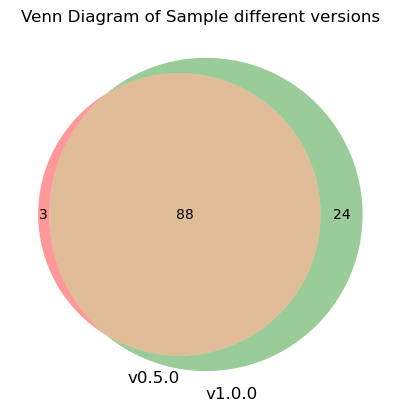

In [6]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import pandas as pd
df_v05 = pd.read_csv('dimer_filtered/results-pep_plddt.txt')
df_v1 = pd.read_csv('./dimer_filtered-protenix_v1/results.txt')

sample_v05 = df_v05['pdb'].tolist()
sample_v1 = df_v1['pdb'].tolist()
# 绘制sample_id之间的韦恩图

venn2([set(sample_v05), set(sample_v1)], set_labels=('v0.5.0', 'v1.0.0'))
plt.title('Venn Diagram of Sample different versions')
plt.show()

In [9]:
diff = set(sample_v05) - set(sample_v1) 
print("In v0.5.0 but not in v1.0.0:")
for item in diff:
    print(item)

In v0.5.0 but not in v1.0.0:
2vzg
5m5r
4bt9


In [11]:
average_rmsd_1 = df_v1['scRMSD'].median()
average_rmsd_05 = df_v05['scRMSD'].median()
print(f"Median scRMSD in v1.0.0: {average_rmsd_1:.4f}")
print(f"Median scRMSD in v0.5.0: {average_rmsd_05:.4f}")

Median scRMSD in v1.0.0: 0.7696
Median scRMSD in v0.5.0: 0.8104


In [4]:
# 比较results-pep_plddt.txt和results.txt之间第二列的区别，
with open('./dimer_filtered/results-pep_plddt.txt', 'r') as f1, open('./dimer_filtered/results.txt', 'r') as f2:
    lines1 = f1.readlines()
    lines2 = f2.readlines()
    set1 = set(line.split(',')[1] for line in lines1)
    set2 = set(line.split(',')[1] for line in lines2)
    diff1 = set1 - set2
    diff2 = set2 - set1
    print("In results-pep_plddt.txt but not in results.txt:")
    for item in diff1:
        print(item)
    print("In results.txt but not in results-pep_plddt.txt:")
    for item in diff2:
        print(item)

In results-pep_plddt.txt but not in results.txt:
1nrl_sample_1_seed_43
In results.txt but not in results-pep_plddt.txt:
5njc_sample_1_seed_44
1nrl_sample_1_seed_42
5n85_sample_2_seed_43


In [17]:
# 从cif转换成pdb格式
import os
from Bio.PDB import MMCIFParser, PDBIO
with open('./dimer_filtered/results.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split(',')
        pdb_code = parts[0]
        sample_name = parts[1]
        cif_path = f'./dimer_filtered/{sample_name}.cif'
        pdb_path = f'./dimer_filtered/{sample_name}.pdb'
        
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(sample_name, cif_path)
        
        io = PDBIO()
        io.set_structure(structure)
        io.save(pdb_path)

## 检查RMSD>2.5时是否有plddt大于85且iptm大于0.7的结构

In [10]:
import numpy as np
import pandas as pd


with open('./dimer/PDB.list', 'r') as f:
    pdbs = [line.strip() for line in f if line.strip()]

# print(pdbs)
total1 = 0
total2 = 0

with open('./dimer_filtered/results.txt', 'w') as result_file:
    for pdb in pdbs:
        df = pd.read_csv(f'./pred/{pdb}/metrics_summary.csv')
        fil_df = df[(df['scRMSD'] <= 2.5)].sort_values(by=['scRMSD'], ascending=True).reset_index(drop=True)
        fil_df2 = df[(df['scRMSD'] <= 2.5) & (df['plddt'] > 85) & (df['iptm'] > 0.7)].sort_values(by=['scRMSD'], ascending=True).reset_index(drop=True)
        count = fil_df['complex'].nunique()
        count2 = fil_df2['complex'].nunique()
        # print(f"{pdb}: {count:>2}")

        total1 += count
        total2 += count2
        if count != count2:
            print(f"Warning: For {pdb}, total count {count} differs from filtered count {count2}.")
    print(f"Total: {total1}")
    print(f"Total with pLDDT>85 and iPTM>0.7: {total2}")

Total: 102
Total with pLDDT>85 and iPTM>0.7: 93


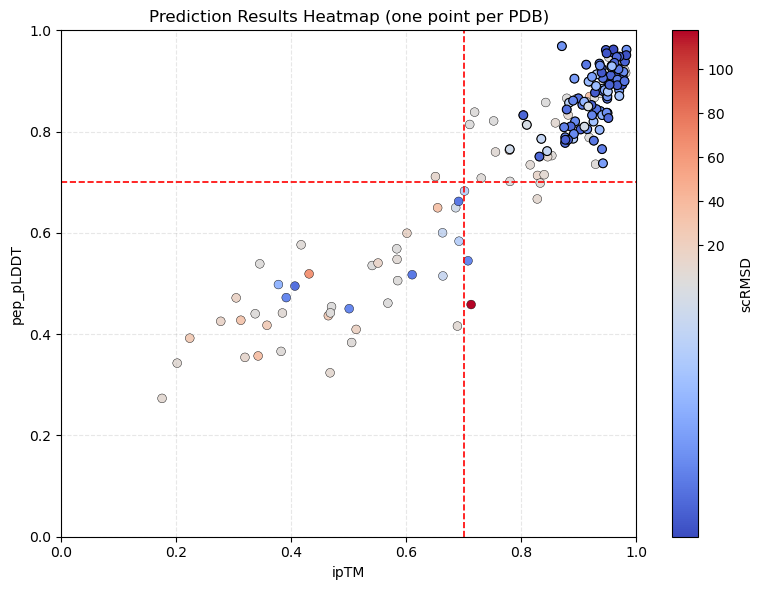

In [9]:
# 将结构预测的结果画成热图，横坐标为 ipTM，纵坐标为 pLDDT，显示 scRMSD 值
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

pred_dir = Path("./pred")
csv_paths = sorted(pred_dir.glob("*/metrics_summary-pep_plddt.csv"))

records = []
for csv_path in csv_paths:
    pdb = csv_path.parent.name
    df = pd.read_csv(csv_path)
    if df.empty or "scRMSD" not in df.columns:
        continue
    # 取 scRMSD 最小的一行作为该 pdb 的预测结果
    best_row = df.loc[df["scRMSD"].idxmin()]
    records.append(
        {
            "pdb": pdb,
            "ipTM": float(best_row["iptm"]),
            "pep_plddt": float(best_row["pep_plddt"]),
            "scRMSD": float(best_row["scRMSD"]),
        }
    )

result_df = pd.DataFrame(records)
if result_df.empty:
    raise ValueError("未找到可用的 metrics_summary.csv 或数据为空。")

plt.figure(figsize=(8, 6))

# 让 scRMSD=2.5 的颜色最突出（以 2.5 为中心的颜色归一化）
vmin = float(result_df["scRMSD"].min())
vmax = float(result_df["scRMSD"].max())
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=2.5, vmax=vmax)

# 先绘制 scRMSD<=2.5 的点，增大尺寸和加粗边框以突出显示
mask = (result_df["scRMSD"] <= 2.5) & (result_df["pep_plddt"] > 0.7) & (result_df["ipTM"] > 0.7)
plt.scatter(
    result_df.loc[mask, "ipTM"],
    result_df.loc[mask, "pep_plddt"],
    c=result_df.loc[mask, "scRMSD"],
    cmap="coolwarm",
    norm=norm,
    s=40,
    alpha=1,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)

scatter = plt.scatter(
    x=result_df["ipTM"],
    y=result_df["pep_plddt"],
    c=result_df["scRMSD"],
    cmap="coolwarm",
    norm=norm,
    s=40,
    alpha=1,
    edgecolors="k",
    linewidths=0.3,
)
cbar = plt.colorbar(scatter, label="scRMSD")



# 绘制分割线：pep_plddt=0.7 与 ipTM=0.7
plt.axhline(0.7, color="red", linestyle="--", linewidth=1.2)
plt.axvline(0.7, color="red", linestyle="--", linewidth=1.2)

plt.xlabel("ipTM")
plt.ylabel("pep_pLDDT")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Prediction Results Heatmap (one point per PDB)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

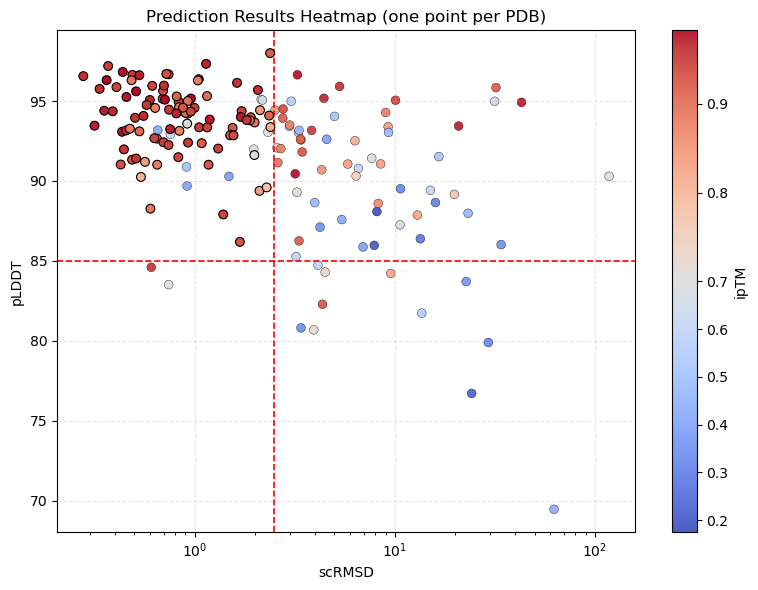

In [1]:
# 将结构预测的结果画成热图，横坐标为 ipTM，纵坐标为 pLDDT，显示 scRMSD 值
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

pred_dir = Path("./pred")
csv_paths = sorted(pred_dir.glob("*/metrics_summary.csv"))

records = []
for csv_path in csv_paths:
    pdb = csv_path.parent.name
    df = pd.read_csv(csv_path)
    if df.empty or "scRMSD" not in df.columns:
        continue
    # 取 scRMSD 最小的一行作为该 pdb 的预测结果
    best_row = df.loc[df["scRMSD"].idxmin()]
    records.append(
        {
            "pdb": pdb,
            "ipTM": float(best_row["iptm"]),
            "pLDDT": float(best_row["plddt"]),
            "scRMSD": float(best_row["scRMSD"]),
        }
    )

result_df = pd.DataFrame(records)
if result_df.empty:
    raise ValueError("未找到可用的 metrics_summary.csv 或数据为空。")

plt.figure(figsize=(8, 6))

# 让 scRMSD=2.5 的颜色最突出（以 2.5 为中心的颜色归一化）
vmin = float(result_df["ipTM"].min())
vmax = float(result_df["ipTM"].max())
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.7, vmax=vmax)

# 先绘制 scRMSD<=2.5 的点，增大尺寸和加粗边框以突出显示
mask = (result_df["scRMSD"] <= 2.5) & (result_df["pLDDT"] > 85) & (result_df["ipTM"] > 0.7)
plt.scatter(
    x=result_df.loc[mask, "scRMSD"],
    y=result_df.loc[mask, "pLDDT"],
    c=result_df.loc[mask, "ipTM"],
    cmap="coolwarm",
    norm=norm,
    s=40,
    alpha=0.95,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)

# change x to log scale
plt.xscale("log")

scatter = plt.scatter(
    x=result_df["scRMSD"],
    y=result_df["pLDDT"],
    c=result_df["ipTM"],
    cmap="coolwarm",
    norm=norm,
    s=40,
    alpha=0.9,
    edgecolors="k",
    linewidths=0.3,
)
cbar = plt.colorbar(scatter, label="ipTM")



# 绘制分割线：pLDDT=85 与 ipTM=0.7
plt.axhline(85, color="red", linestyle="--", linewidth=1.2)
plt.axvline(2.5, color="red", linestyle="--", linewidth=1.2)

plt.xlabel("scRMSD")
plt.ylabel("pLDDT")
plt.title("Prediction Results Heatmap (one point per PDB)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()